# Predictive Modeling on Titanic Dataset

In this notebook, we will build and evaluate predictive models on the Titanic dataset. We will follow these steps:
- Load the cleaned Titanic dataset
- Perform data preprocessing
- Train multiple classifiers
- Evaluate model performance
- Hyperparameter tuning
- Compare models


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import joblib


In [2]:
# Load the Titanic dataset
df = pd.read_csv('titanic_cleaned.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Data Preprocessing
# Define features and target variable
X = df.drop('survived', axis=1)
y = df['survived']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define preprocessing for numerical and categorical features
numeric_features = ['age', 'fare']
categorical_features = ['sex', 'embarked', 'pclass']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [4]:
# Create a pipeline for Random Forest Classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the model
rf_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))


Random Forest Classifier Metrics:
Accuracy: 0.8156424581005587
Precision: 0.78125
Recall: 0.7246376811594203
F1 Score: 0.7518796992481203
ROC AUC: 0.7986824769433466


Decision Tree Classifier Metrics:
Accuracy: 0.8100558659217877
Precision: 0.7692307692307693
Recall: 0.7246376811594203
F1 Score: 0.746268656716418
ROC AUC: 0.7941370223978921


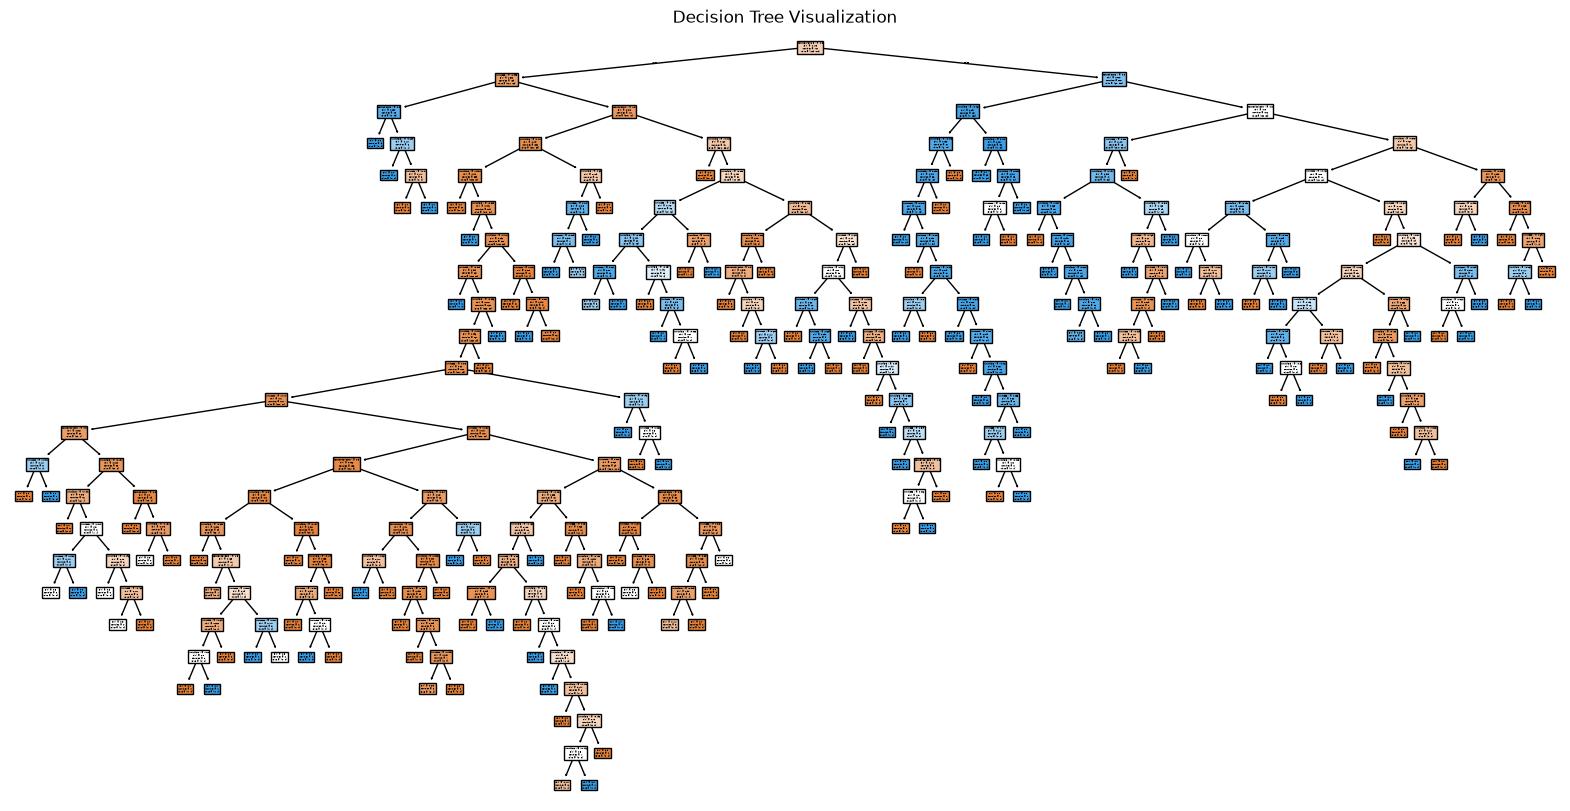

In [5]:
# Create a pipeline for Decision Tree Classifier
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Train the model
dt_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_pipeline.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, y_pred_dt))

# Visualize the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt_pipeline.named_steps['classifier'], feature_names=preprocessor.get_feature_names_out(), filled=True)
plt.title('Decision Tree Visualization')
plt.show()

In [6]:
# Create a pipeline for Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Train the model
lr_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate the model
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_pred_lr))


Logistic Regression Metrics:
Accuracy: 0.770949720670391
Precision: 0.71875
Recall: 0.6666666666666666
F1 Score: 0.6917293233082706
ROC AUC: 0.7515151515151515


In [8]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20]
}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

print("Best parameters for Random Forest:", grid_search.best_params_)
print("Best ROC AUC score from Grid Search:", grid_search.best_score_)


Best parameters for Random Forest: {'classifier__max_depth': 10, 'classifier__n_estimators': 50}
Best ROC AUC score from Grid Search: 0.8669521231119978


In [9]:
# Save the best model
joblib.dump(grid_search.best_estimator_, 'best_rf_model.joblib')

# Load the model and make predictions
loaded_model = joblib.load('best_rf_model.joblib')
y_pred_loaded = loaded_model.predict(X_test)
print("Loaded Model Accuracy:", accuracy_score(y_test, y_pred_loaded))


Loaded Model Accuracy: 0.8212290502793296


# Conclusion

In this notebook, we built and evaluated three different classifiers on the Titanic dataset. We performed hyperparameter tuning on the Random Forest model and saved the best model for future use. The evaluation metrics for each model were reported, and the best parameters for the Random Forest model were identified.